In [7]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/vuppalaadithyasairam/thermography-images-of-diabetic-foot/ThermoDataBase/val/DM Group/DM010_M_L-rotated2.png
/kaggle/input/datasets/vuppalaadithyasairam/thermography-images-of-diabetic-foot/ThermoDataBase/val/DM Group/DM002_M_L-sharpened.png
/kaggle/input/datasets/vuppalaadithyasairam/thermography-images-of-diabetic-foot/ThermoDataBase/val/DM Group/DM010_M_L-sharpened.png
/kaggle/input/datasets/vuppalaadithyasairam/thermography-images-of-diabetic-foot/ThermoDataBase/val/DM Group/DM013_F_R-sharpened.png
/kaggle/input/datasets/vuppalaadithyasairam/thermography-images-of-diabetic-foot/ThermoDataBase/val/DM Group/DM011_F_L-sharpened.png
/kaggle/input/datasets/vuppalaadithyasairam/thermography-images-of-diabetic-foot/ThermoDataBase/val/DM Group/DM019_F_R-rotated2.png
/kaggle/input/datasets/vuppalaadithyasairam/thermography-images-of-diabetic-foot/ThermoDataBase/val/DM Group/DM020_F_L-rotated1.png
/kaggle/input/datasets/vuppalaadithyasairam/thermography-images-of-diabe

In [8]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models

tf.random.set_seed(42)
np.random.seed(42)

In [9]:
DATA_DIR = '/kaggle/input/datasets/vuppalaadithyasairam/thermography-images-of-diabetic-foot/ThermoDataBase/train'
BATCH_SIZE = 32
IMG_SIZE = (224, 224)

train_ds = keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary"  # "Control Group" vs "DM Group"
)

val_ds = keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary"
)

class_names = train_ds.class_names
print(f"Class names: {class_names}")

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

Found 1444 files belonging to 2 classes.
Using 1156 files for training.


I0000 00:00:1784104647.371678      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1784104647.374551      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 1444 files belonging to 2 classes.
Using 288 files for validation.
Class names: ['Control Group', 'DM Group']


In [10]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
])


base_model = keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

inputs = layers.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)

# MobileNetV2 expects inputs scaled between -1 and 1
x = keras.applications.mobilenet_v2.preprocess_input(x)

x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)

outputs = layers.Dense(1, activation='sigmoid')(x)

model = models.Model(inputs, outputs)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.BinaryCrossentropy(),
    metrics=['accuracy']
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [14]:
# Phase 1: Train the Head (Warm-up)
print("--- Phase 1: Training Classification Head ---")
history_warmup = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30
)

# Phase 2: Unfreeze and Fine-Tune the Backbone
print("\n--- Phase 2: Unfreezing Top Layers for Fine-Tuning ---")
base_model.trainable = True

# Freeze everything except the top 20 layers
for layer in base_model.layers[:-20]:
    layer.trainable = False

# Recompile with a significantly lower learning rate for fine-tuning
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss=keras.losses.BinaryCrossentropy(),
    metrics=['accuracy']
)

# Early stopping to catch the peak validation accuracy
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_accuracy', 
    patience=3, 
    restore_best_weights=True
)

history_finetune = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[early_stopping]
)

--- Phase 1: Training Classification Head ---
Epoch 1/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 76ms/step - accuracy: 0.9792 - loss: 0.0758 - val_accuracy: 0.9097 - val_loss: 0.2003
Epoch 2/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 76ms/step - accuracy: 0.9784 - loss: 0.0740 - val_accuracy: 0.9167 - val_loss: 0.2120
Epoch 3/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 76ms/step - accuracy: 0.9801 - loss: 0.0667 - val_accuracy: 0.9201 - val_loss: 0.1979
Epoch 4/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 76ms/step - accuracy: 0.9870 - loss: 0.0536 - val_accuracy: 0.9201 - val_loss: 0.1981
Epoch 5/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 77ms/step - accuracy: 0.9827 - loss: 0.0568 - val_accuracy: 0.9306 - val_loss: 0.1702
Epoch 6/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 77ms/step - accuracy: 0.9896 - loss: 0.0495 - val_accuracy: 0.9236 - val_loss: 0.1685
Epoch 7/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 78ms/step - accuracy: 0.9827 - loss: 0.0532 - val_accuracy: 0.9167 - val_loss: 0.2073
Epoch 8/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 78ms/step - accuracy: 0.

=== Validation Performance Metrics ===
Accuracy:     98.96%
Precision:    98.72%  (Out of all predicted DM, how many were actually DM?)
Recall/Sens:  99.35%  (Out of all actual DM, how many did we catch?)
F1-Score:     99.04%  (Harmonic mean of Precision and Recall)



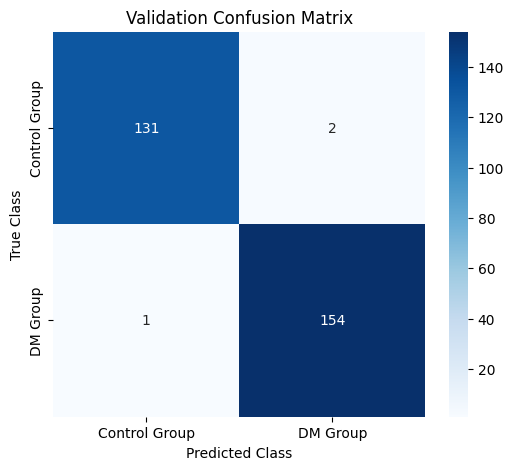

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Collect all ground truth labels and model predictions manually
all_labels = []
all_preds = []

for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    # Convert probability thresholds (0.5) to binary labels
    pred_labels = (preds > 0.5).astype(int)
    
    all_labels.extend(labels.numpy().flatten())
    all_preds.extend(pred_labels.flatten())

all_labels = np.array(all_labels)
all_preds = np.array(all_preds)

# --- Metric Calculations ---

# 1. Accuracy
accuracy = np.mean(all_labels == all_preds)

# 2. Confusion Matrix Components
# Assumes 1 = DM Group (Positive), 0 = Control Group (Negative)
tp = np.sum((all_labels == 1) & (all_preds == 1))
fp = np.sum((all_labels == 0) & (all_preds == 1))
fn = np.sum((all_labels == 1) & (all_preds == 0))
tn = np.sum((all_labels == 0) & (all_preds == 0))

# 3. Precision, Recall, F1, and Specificity
# Added a tiny epsilon (1e-7) to prevent zero-division errors if a metric is 0
precision = tp / (tp + fp + 1e-7)
recall = tp / (tp + fn + 1e-7)  # Also known as Sensitivity
f1_score = 2 * (precision * recall) / (precision + recall + 1e-7)

# Print Summary Report
print("=== Validation Performance Metrics ===")
print(f"Accuracy:     {accuracy:.2%}")
print(f"Precision:    {precision:.2%}  (Out of all predicted DM, how many were actually DM?)")
print(f"Recall/Sens:  {recall:.2%}  (Out of all actual DM, how many did we catch?)")
print(f"F1-Score:     {f1_score:.2%}  (Harmonic mean of Precision and Recall)")
print("======================================\n")

# --- Plotting ---
cm = np.array([[tn, fp], [fn, tp]])

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Validation Confusion Matrix')
plt.ylabel('True Class')
plt.xlabel('Predicted Class')
plt.show()

